# Numbers-of-record audit: checking every paper number against its source

This notebook is a runnable walk-through of **`eval.py`**, the evaluation artifact *"Check every paper number against its source"* (iteration 5, FIX slot). The artifact audits the research report `iter_5/gen_strat/current_report.md` before the paper is written. It is read-only, CPU-only and costs $0.

**What the audit does**

1. **Freeze** the universe of cited numbers, hashing every report token and every curated claim, before any source file is opened.
2. For each curated **registry claim**, locate the number the report prints, using a regex and the line closest to a hint. Then read the claim's *intended* source value (`relpath::key` in an earlier artifact) and compare the two under a **frozen match rule**, which uses the shown decimals, significant figures and the side of 0.05.
3. When the numbers do not match, try **alternate** sources (another estimator, fold or definition) to classify the mismatch as `WRONG_ESTIMATOR`, `WRONG_DEFINITION`, `DRIFT_VALUE` or `NOT_TRACEABLE`. **Tier-C** numbers are also recomputed from row-level data.
4. Build the **report-drift list**, with the correct text and a severity grade, and the aggregate metrics M1–M4.
5. **Seeded-error injection (M5)**: plant digit changes, CI-bound swaps, fold relabels and verdict flips in a scratch copy of the report. Then re-run the detector *blind* to measure recall.

**What this demo keeps and what it changes.** The matching, flagging, drift, metric and injection code is the original, copied as-is. The only difference is *where source values come from*. The original reads about 20 sibling artifacts of the run (JSON, CSV and parquet files that are not on GitHub). Here, every source and alternate value of a curated set of **100 of the 319 registry claims** was resolved **once** from those files. They ship in `mini_demo_data.json` together with the full audited report text. The curated set holds every non-OK claim, every headline claim, and a block-stratified sample of OK and MISSING claims. Two parts need files that are not shipped and are skipped: the decision-rule, verdict-cell and text-assertion checks (`checks.py`), and the auto-scan's 3.8M-value artifact index. The index-free CI-structure check of the auto-scan still runs.

## Setup
Install the dependencies. `loguru` is not pre-installed on Colab. `numpy`, `pandas` and `matplotlib` are, so they are installed at Colab's versions only when running outside Colab.

In [1]:
%%capture
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')

Imports: the original `eval.py` and `audit_core.py` import blocks, plus `pandas` and `matplotlib` for the result tables and plots at the end.

In [2]:
from __future__ import annotations

# --- eval.py imports (original) ---
import hashlib
import json
import math
import random
import re
import resource
import subprocess
import sys
import time
from collections import Counter, defaultdict
from datetime import datetime, timezone
from pathlib import Path

from loguru import logger

# --- audit_core.py imports (original) ---
import csv
import os
from dataclasses import dataclass, field
from functools import lru_cache
from typing import Any

import numpy as np

# --- notebook-only additions ---
import types
import pandas as pd
import matplotlib.pyplot as plt

## Data loading
`mini_demo_data.json` is fetched from the paper repository on GitHub, falling back to a local copy. It contains:
- `report_lines`: the full audited report text;
- `hypothesis_text`: the hypothesis text that some claims are also matched against;
- `claims`: 100 curated registry entries (from `registry.py`), each with its report regex, source spec, alternates, kind, tier and the flag the original run gave it (`expected_flag`);
- `source_values`: the value behind every `relpath::key` / `recompute:*` spec, resolved once from the run's artifacts;
- `tierc_recomputed`: the tier-C IRR recomputes, `exp(b·SD)` over the reconstructed estimation sample from the parquet event files;
- `original_metrics`: `metrics_agg` of the original full run, for comparison.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/fork/run_YczZzZ0_9kfq/round-5/evaluation-8/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"{len(data['report_lines'])} report lines, {len(data['claims'])} curated claims, "
      f"{len(data['source_values'])} pre-resolved source specs, {len(data['tierc_recomputed'])} tier-C recomputes")

972 report lines, 100 curated claims, 103 pre-resolved source specs, 11 tier-C recomputes


## Config
All tunable parameters of the audit. The whole notebook runs in seconds, so the defaults are the original values: all 100 shipped claims and 10 seeded errors per type. The original audit used 319 claims, and only 100 ship with the demo.

In [5]:
N_CLAIMS = 100            # registry claims to audit (demo max 100 = all shipped; original run: 319)
N_PER_TYPE = 10           # seeded errors per error type in M5 (original: 10)
SEED = 20260929           # pre-registered injection seed (original)
SEED_BLIND = 20260930     # fresh draw used for the reported (blind) M5 after the detector fix (original)
RUN_SEEDED_INJECTION = True

Output folders and logging, as at the top of `eval.py`. `WS` was the artifact folder (`Path(__file__).parent`). Here it is a local `audit_demo_out/` folder. The 24 GB `RLIMIT_AS` cap is left out because a notebook kernel is already memory-bounded.

In [6]:
WS = Path("audit_demo_out")  # original: Path(__file__).resolve().parent
(WS / "logs").mkdir(parents=True, exist_ok=True)
(WS / "results").mkdir(exist_ok=True)
(WS / "tables").mkdir(exist_ok=True)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(str(WS / "logs" / "run.log"), rotation="30 MB", level="DEBUG")
# resource.setrlimit(resource.RLIMIT_AS, (24 * 1024 ** 3, 24 * 1024 ** 3))  # original script-level memory cap

2

## `audit_core.py`: report tokenizer, frozen match rule and source access
This cell copies `audit_core.py` as-is, with one exception: **`read_source`**. The original splits `relpath::key` and reads the file under the run root. Here the value was resolved from that same file once in advance, and it is looked up in `data["source_values"]`. Everything else in the cell is the original code:
- the flag taxonomy;
- the match rule (`match_value`), which compares at the precision the report shows;
- the number regex (`NUM_RE`);
- `parse_reported`;
- the tokenizer, which tells years, reference numbers, labels such as "Table 16" and hashes apart from real numbers;
- the section helpers.

In [7]:
REPORT_REL = data["report_path"]      # "3_invention_loop/iter_5/gen_strat/current_report.md"
HYPO_REL = data["hypothesis_path"]

# ---------------------------------------------------------------- flags / rule
FLAGS = ["OK", "DRIFT_VALUE", "WRONG_ESTIMATOR", "WRONG_DEFINITION", "WRONG_FOLD",
         "NOT_TRACEABLE", "VERDICT_DRIFT", "MISSING_IN_REPORT"]
MATCH_RULE = {
    "counts_and_n_G": "exact equality after removing thousands separators",
    "continuous_and_ci_bounds": "|source - reported| <= 0.5 * 10^-d (+1e-9), d = decimals shown in the report; "
                                 "percentages compare source*100 at the shown decimals",
    "p_values": "equal after rounding the source to the reported significant figures (or 'p < x' holds), AND same side "
                "of 0.05, AND same side of the Holm threshold when one is attached to the claim",
    "verdicts": "the verdict string must equal the one the decision rule gives on the source numbers",
    "ci_structure": "a reported 'x [lo, hi]' must satisfy lo <= hi and lo <= x <= hi at the shown precision",
}
FLAG_DEFS = {
    "OK": "value/verdict matches its intended source under the match rule",
    "DRIFT_VALUE": "a source exists for the intended quantity but the reported value differs and matches no alternative",
    "WRONG_ESTIMATOR": "the number is real but comes from a different estimator/spec/model than the one the text names",
    "WRONG_DEFINITION": "the number or sentence is real but is given a wrong meaning (e.g. OR read as a risk ratio)",
    "WRONG_FOLD": "screen number labelled held-out (or the reverse), or MeSH/main mixed",
    "NOT_TRACEABLE": "no file contains the number; a replacement value is given or the number is dropped",
    "VERDICT_DRIFT": "the verdict stated differs from what the frozen decision rule gives on the source numbers",
    "MISSING_IN_REPORT": "a number of record (hypothesis evidence list / artifact output) that the report never states",
}

NUM_RE = re.compile(r"(?<![\w.\^])([−\-+]?)(\d[\d,]*(?:\.\d+)?|\.\d+)(?:\s?[×x]\s?10\^?([−\-]?\d+)|e([−\-]?\d+))?(%?)(?![\w])")
MINUS = str.maketrans({"−": "-", "–": "-", "‑": "-"})


@dataclass
class Reported:
    """A reported number as written, with its precision."""
    text: str
    value: float
    decimals: int
    sig: int
    is_pct: bool
    is_sci: bool
    lt: bool = False  # 'p < x'


def parse_reported(s: str) -> Reported | None:
    """Parse '1,544', '−0.391', '26%', '9.7e-5', '1e-5', '< 0.001', '1.4e-13'."""
    t = s.strip().translate(MINUS).replace(" ", "").replace(" ", "")
    lt = False
    if t.startswith("<"):
        lt, t = True, t[1:]
    if t.startswith("≤"):
        lt, t = True, t[1:]
    is_pct = t.endswith("%")
    t = t.rstrip("%")
    m = re.fullmatch(r"([+\-]?)(\d[\d,]*(?:\.\d+)?|\.\d+)(?:e([+\-]?\d+)|[×x]10\^?([+\-]?\d+))?", t)
    if not m:
        return None
    sign, mant, e1, e2 = m.groups()
    mant_clean = mant.replace(",", "")
    exp = e1 or e2
    val = float(mant_clean) * (10 ** int(exp) if exp else 1.0)
    if sign == "-":
        val = -val
    dec = len(mant_clean.split(".")[1]) if "." in mant_clean else 0
    digits = mant_clean.replace(".", "").lstrip("0")
    sig = max(1, len(digits))
    if exp:
        dec = dec - int(exp)
    return Reported(text=s.strip(), value=val, decimals=dec, sig=sig, is_pct=is_pct, is_sci=bool(exp), lt=lt)


def round_sig(x: float, sig: int) -> float:
    if x == 0 or not math.isfinite(x):
        return x
    return round(x, sig - int(math.floor(math.log10(abs(x)))) - 1)


def match_value(rep: Reported, src: float, kind: str = "cont", holm_threshold: float | None = None,
                sign_mode: str = "signed") -> bool:
    """Frozen match rule (see MATCH_RULE)."""
    if src is None or (isinstance(src, float) and not math.isfinite(src)):
        return False
    src = float(src)
    rv = rep.value
    if sign_mode == "abs":
        src, rv = abs(src), abs(rv)
    if kind == "count":
        return abs(src - rv) < 1e-9
    if kind == "pct":  # source is a fraction, report in percent
        src = src * 100.0
        return abs(src - rv) <= 0.5 * 10 ** (-rep.decimals) + 1e-9
    if kind == "p":
        if rep.lt:
            ok = src < rv + 1e-15
        elif rep.is_sci or rv < 0.001:
            ok = abs(round_sig(src, rep.sig) - rv) <= 1e-12 * max(1.0, abs(rv)) or \
                abs(src - rv) <= 0.5 * 10 ** (-rep.decimals) + 1e-15
        else:
            ok = abs(src - rv) <= 0.5 * 10 ** (-rep.decimals) + 1e-12 or abs(round_sig(src, rep.sig) - rv) < 1e-12
        same_side = (src < 0.05) == (rv < 0.05) or rep.lt
        if holm_threshold is not None:
            same_side = same_side and ((src < holm_threshold) == (rv < holm_threshold) or rep.lt)
        return ok and same_side
    # continuous
    return abs(src - rv) <= 0.5 * 10 ** (-rep.decimals) + 1e-9


# ---------------------------------------------------------------- source access
SOURCE_VALUES = data["source_values"]


def read_source(spec: str) -> Any:
    # original: rel, key = spec.split("::", 1); return get_by_key(rel, key)   -> opens <run root>/rel and walks the key.
    # demo: the same value, resolved once from that file by build_mini_demo_data.py, looked up in the snapshot.
    s = SOURCE_VALUES[spec]
    if s["error"]:
        raise KeyError(s["error"])
    return s["value"]


# ---------------------------------------------------------------- report parsing
@dataclass
class Token:
    line: int  # 1-based
    col: int
    text: str
    rep: Reported
    kind: str  # 'year', 'ref', 'num'
    section: str = ""


YEAR_OK = range(1985, 2031)


def tokenize_line(text: str, lineno: int) -> list[Token]:
    toks: list[Token] = []
    if re.match(r"^\[\d+\]\s", text):  # reference list entries
        return toks
    for m in NUM_RE.finditer(text):
        sign, mant, e_x, e_e, pct = m.groups()
        s = (sign or "") + mant + (f"e{(e_x or e_e)}" if (e_x or e_e) else "") + (pct or "")
        rep = parse_reported(s)
        if rep is None:
            continue
        start = m.start()
        before = text[max(0, start - 12):start]
        after = text[m.end():m.end() + 3]
        kind = "num"
        if re.search(r"\[$", before) and after.startswith("]") and "." not in mant and "," not in text[m.end():m.end() + 1]:
            kind = "ref"
        elif re.search(r"(Table|Artifact|Iteration|iteration|Figure|activity|Activity|F\d|M|m|R|E|S|G|W|k|C|D|H|Y)\s?$", before) and "." not in mant and not pct:
            # 'Table 16', 'Artifact 12', 'M3', 'R1', 'E4', 'G2', 'W2', 'Y3' identifiers
            kind = "label" if re.search(r"(Table|Artifact|Iteration|iteration|Figure|activity|Activity)\s$", before) or re.search(r"[A-Za-z]$", before) else "num"
        if kind == "num" and "." not in mant and "," not in mant and not pct and rep.value in YEAR_OK and not sign:
            kind = "year"
        if kind == "num" and re.search(r"(sha|SHA|hash|\.\.\.)", text[max(0, start - 30):m.end() + 6]) and re.search(r"[0-9a-f]{6,}", text[max(0, start - 10):m.end() + 10]):
            kind = "hash"
        toks.append(Token(line=lineno, col=start, text=s, rep=rep, kind=kind))
    return toks


def sections(lines: list[str]) -> list[tuple[int, int, str]]:
    """(start, end, heading) 1-based inclusive ranges for '#'/'##'/'###' headings."""
    heads = [(i + 1, l.strip("# ").strip()) for i, l in enumerate(lines) if l.startswith("#")]
    out = []
    for j, (s, h) in enumerate(heads):
        e = heads[j + 1][0] - 1 if j + 1 < len(heads) else len(lines)
        out.append((s, e, h))
    return out


def iteration_of_line(lines: list[str], lineno: int) -> int:
    it = 0
    for i in range(lineno):
        m = re.match(r"^# Iteration (\d)", lines[i])
        if m:
            it = int(m.group(1))
    return it


# eval.py refers to these as AC.<name> (`import audit_core as AC`)
AC = types.SimpleNamespace(FLAGS=FLAGS, MATCH_RULE=MATCH_RULE, FLAG_DEFS=FLAG_DEFS, MINUS=MINUS, REPORT_REL=REPORT_REL, HYPO_REL=HYPO_REL,
                           parse_reported=parse_reported, match_value=match_value, read_source=read_source,
                           tokenize_line=tokenize_line, sections=sections, iteration_of_line=iteration_of_line)
print(parse_reported("−0.391"), "|", match_value(parse_reported("1.30"), 1.300076888, "cont"))

Reported(text='−0.391', value=-0.391, decimals=3, sig=3, is_pct=False, is_sci=False, lt=False) | True


## Registry and `eval.py` constants
`CLAIMS` is the curated registry from `registry.py`, the first `N_CLAIMS` of the 100 shipped entries. Each entry has these fields:
- `rep`: a (hint line, regex) pair that locates the reported number in the report;
- `src`: the *intended* source;
- `alt`: a list of (flag, alternate source) pairs used to classify a mismatch;
- `kind`: `cont`, `count`, `p` or `pct`, which selects the match rule;
- `tier`: R means the number is re-read from a summary file, and C means it is recomputed.

The known-drift list is the plan's gate. The original audit had to detect all 12 items.

In [8]:
CLAIMS = data["claims"][:N_CLAIMS]  # original: from registry import CLAIMS (319 claims)

KNOWN_DRIFT = {  # the plan's known-drift list (gate: recall must be 100%)
    "K01_rq1_rescue_summary": "RQ1 rescue in the summary paragraph (line ~7)",
    "K02_learned_heading": "'What we have learned' heading rescues RQ1 (line ~867)",
    "K03_fig_methodology": "fig_methodology description (rescued R1, OR 3.14, placement)",
    "K04_26of27": "'26 of 27' robustness (lines ~486 note vs ~551)",
    "K05_primary_CT_p": "primary CT p 0.48 vs 0.85",
    "K06_83pct": "'83% single-paper'",
    "K08_table20": "Table 20's 1.14 / 1.09",
    "K09_or_31x": "'3.1x more likely'",
    "K10_neg_plac_matching": "NEG/PLAC/matching descriptions",
    "K11_k2_mesh": "'k = 2 replicates on ... MeSH'",
    "K12_mesh_leadlag": "'directionally consistent' MeSH lead-lag",
    "K14_establishment": "'host-native partners predict establishment' while EST_bin is null",
}
EXTRA_KNOWN = {"K13_constraint_mixed": "Table 20c constraint row mixes pooled-panel screen with event-study held-out (review item)"}
BLOCK_ORDER = ["D2", "MeSH", "RQ1", "descriptive", "adopter", "data"]
print(f"{len(CLAIMS)} claims; by block {dict(Counter(c['block'] for c in CLAIMS))}")

100 claims; by block {'D2': 33, 'MeSH': 16, 'RQ1': 18, 'descriptive': 10, 'adopter': 18, 'data': 5}


## Helpers and Step 0: freeze the universe
`find_rep` locates a reported number with the claim's regex. When the regex matches on several lines, the match nearest the hint line wins. `freeze` writes `audit_spec.json` and `audit_universe.json` **before any source value is read**, which is the pre-registration step. The only change is the report and hypothesis hashes: they are computed from the loaded text, not from the files on the run volume. The report is the full audited text, so the report hash equals the original run's `report_sha256`.

In [9]:
# ============================================================ helpers
def sha(s: str | bytes) -> str:
    return hashlib.sha256(s if isinstance(s, bytes) else s.encode()).hexdigest()


def find_rep(lines: list[str], hint: int, regex: str) -> tuple[int, str] | None:
    """Locate a reported number by regex; the match nearest the hint line wins."""
    rx = re.compile(regex)
    best = None
    for i, l in enumerate(lines):
        m = rx.search(l)
        if m:
            d = abs(i + 1 - hint)
            if best is None or d < best[0]:
                best = (d, i + 1, m.group(1))
    return (best[1], best[2]) if best else None


def fmt(v) -> str:
    if v is None:
        return ""
    if isinstance(v, float):
        if v != 0 and (abs(v) < 1e-3 or abs(v) >= 1e6):
            return f"{v:.3e}"
        return f"{v:.6g}"
    return str(v)


# ============================================================ step 0: freeze the universe
def build_universe(lines: list[str], hypo_text: str) -> dict:
    toks = []
    for i, l in enumerate(lines):
        for t in AC.tokenize_line(l, i + 1):
            toks.append(dict(line=t.line, col=t.col, text=t.text, kind=t.kind))
    reg = []
    for c in CLAIMS:
        rv = find_rep(lines, c["rep"][0], c["rep"][1]) if c["rep"] else None
        hv = None
        if c.get("hyp"):
            m = re.search(c["hyp"], hypo_text)
            hv = m.group(1) if m else None
        reg.append(dict(id=c["id"], block=c["block"], report_line=rv[0] if rv else None, report_value=rv[1] if rv else None,
                        hyp_value=hv, src=c["src"], alt=[a[1] for a in c["alt"]]))
    verdict_words = [(i + 1, w) for i, l in enumerate(lines) for w in re.findall(
        r"\b(CONFIRMED|DEAD|GRAFTING|NEITHER|REPLICATED|NULL|MIXED|TRIGGERED|NOT MET|PASS|FAIL|SUPPORT|NOT SUPPORTED|R1_DEAD)\b", l)]
    return dict(tokens=toks, registry=reg, verdict_words=verdict_words)


def freeze(lines: list[str], hypo_text: str) -> dict:
    uni = build_universe(lines, hypo_text)
    uni_json = json.dumps(uni, sort_keys=True, ensure_ascii=False)
    spec = dict(
        artifact="gen_art_evaluation_8 (iteration 5, FIX slot): numbers-of-record audit",
        frozen_utc=datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ"),
        note="Frozen before any source file is opened: universe of cited numbers, match rule, flag taxonomy, known-drift list, "
             "seeded-injection design. Sources are only read after this file is written.",
        # original: sha((AC.RUN_ROOT / AC.REPORT_REL).read_bytes()) / same for the hypothesis file
        report=AC.REPORT_REL, report_sha256=sha("\n".join(lines)),
        hypothesis=AC.HYPO_REL, hypothesis_sha256=sha(hypo_text),
        universe_sha256=sha(uni_json), n_report_tokens=len(uni["tokens"]),
        n_report_tokens_by_kind=dict(Counter(t["kind"] for t in uni["tokens"])),
        n_registry_claims=len(uni["registry"]), n_verdict_words=len(uni["verdict_words"]),
        match_rule=AC.MATCH_RULE, flags=AC.FLAG_DEFS, known_drift=KNOWN_DRIFT, extra_known=EXTRA_KNOWN,
        severity_grades={"VERDICT-CHANGING": "the correct number/verdict changes a significance side, a CI-excludes-null statement or a decision-rule outcome",
                         "NUMBER-ONLY": "value differs but no conclusion changes", "WORDING": "definition/label/scope wording"},
        tiers={"R": "re-read from a summary JSON/CSV", "C": "recomputed from row-level files or from primitive quantities (Holm, IVW, counts, prevalences)"},
        seeded_injection=dict(seed=SEED, n_per_type=N_PER_TYPE, types=["digit_change", "ci_bound_swap", "estimator_fold_relabel", "verdict_flip"],
                              target_recall=0.95, blind="the detector receives only the perturbed text"),
        independent_rederivation=dict(n_sample=50, min_per_block=8, plus="all headline/verdict-bearing numbers", seed=SEED),
    )
    (WS / "results" / "audit_universe.json").write_text(uni_json)
    (WS / "results" / "audit_spec.json").write_text(json.dumps(spec, indent=2, ensure_ascii=False))
    spec["_audit_spec_sha256"] = sha((WS / "results" / "audit_spec.json").read_bytes())
    logger.info(f"FROZEN universe sha256 {spec['universe_sha256'][:16]} ({len(uni['tokens'])} tokens, {len(uni['registry'])} claims) at {spec['frozen_utc']}")
    return dict(spec=spec, universe=uni)

## Step 1: evaluate each registry claim
`evaluate_claim` is the core of the audit and is copied as-is. For one claim it:
1. finds the reported value, and the hypothesis value if the claim has one;
2. reads the intended source and compares the two under the match rule;
3. on a mismatch, walks the alternates to classify the error; if nothing matches, the flag is `DRIFT_VALUE`, or `NOT_TRACEABLE` when the claim has no source;
4. for tier-C headline IRRs, requires the recomputed value `exp(b·SD(A_cont))` to agree as well.

Two small functions are adapted:
- `source_value`: the original sends `recompute:*` specs to `checks.RECOMPUTE`, which recomputes from row-level files. Here both kinds of spec go through the snapshot lookup.
- `tierc_irr`: the original loads the parquet event files, prunes fixed-effect groups with an all-zero outcome or a singleton event (`_prune`), and computes `exp(b·SD)`. Here it returns that same recomputed value from the snapshot.

In [10]:
# ============================================================ step 1: evaluate registry claims
def source_value(spec: str):
    # original: `import checks`; recompute:* -> checks.RECOMPUTE[name]() on row-level files, else AC.read_source(spec).
    # demo: both kinds were resolved once into data["source_values"].
    return AC.read_source(spec)


TIERC_IRR = {  # headline IRR rows recomputed from primitives b, se and the row-level SD of A_cont
    "d2.scr.cop.irr": ("screen", "irr"), "d2.scr.cop.lo": ("screen", "lo"), "d2.scr.cop.hi": ("screen", "hi"),
    "d2.ho.cop.irr": ("heldout", "irr"), "d2.ho.cop.irr_sum": ("heldout", "irr"), "d2.ho.cop.lo": ("heldout", "lo"), "d2.ho.cop.hi": ("heldout", "hi"),
    "g4.R2.irr": ("mesh", "irr"), "g4.R2.irr_sum": ("mesh", "irr"), "g4.R2.lo": ("mesh", "lo"), "g4.R2.hi": ("mesh", "hi"),
}
TIERC_SNAPSHOT = {TIERC_IRR[cid]: v for cid, v in data["tierc_recomputed"].items()}


def tierc_irr(which: str, part: str) -> tuple[float, str]:
    """IRR/SD recomputed as exp(b * SD(A_cont)) with SD over the reconstructed co-primary estimation sample
    (row-level events, concept + e + d FE groups pruned for all-zero outcomes and singletons); CI from b +- 1.96 se."""
    # original: reads the screen / held-out / MeSH parquet event file, _prune(ev, ["concept_id", "e", "d"]),
    # sd = p.A_cont.std(); val = exp(b*sd) (lo/hi: exp((b -+ 1.96 se)*sd)). demo: that value from the snapshot.
    r = TIERC_SNAPSHOT[(which, part)]
    return r["value"], r["method"]


def evaluate_claim(c: dict, lines: list[str], hypo_text: str) -> dict:
    out = dict(id=c["id"], block=c["block"], claim=c["claim"], fold_label=c["fold"], estimator=c["estimator"], artifact=c["art"],
               tier=c["tier"], headline=c["headline"], known=c.get("known") or "")
    rv = find_rep(lines, c["rep"][0], c["rep"][1]) if c["rep"] else None
    hv = None
    if c.get("hyp"):
        m = re.search(c["hyp"], hypo_text)
        hv = m.group(1) if m else None
    out.update(report_line=rv[0] if rv else "", report_value=rv[1] if rv else "", hyp_value=hv or "")
    out["source"] = c["src"] or ""
    sv, err = None, ""
    if c["src"]:
        try:
            sv = source_value(c["src"])
        except (KeyError, IndexError, FileNotFoundError, ValueError, TypeError, StopIteration) as e:
            err = f"{type(e).__name__}: {e}"
            logger.warning(f"source read failed for {c['id']}: {err}")
    out["source_value"] = sv if not isinstance(sv, str) else sv
    out["source_error"] = err
    out["recomputed"] = ""
    out["recompute_method"] = "recompute function (row-level / primitives)" if (c["src"] or "").startswith("recompute:") else "re-read"
    if c["id"] in TIERC_IRR:
        try:
            v, how = tierc_irr(*TIERC_IRR[c["id"]])
            out["recomputed"], out["recompute_method"] = v, how
        except (KeyError, FileNotFoundError, ValueError, TypeError) as e:
            out["recompute_method"] = f"tier-C recompute failed: {e}"
            out["tier"] = "R"
    compare_str = out["report_value"]
    rep = AC.parse_reported(compare_str) if compare_str else None
    kind = c["kind"]
    if rep is not None and rep.is_pct and kind == "cont":
        kind = "pct"
    if kind == "pctval":
        kind = "cont"

    def m(val) -> bool:
        return rep is not None and isinstance(val, (int, float)) and AC.match_value(rep, float(val), kind, c.get("holm"), c.get("sign", "signed"))

    flag, alt_used = None, ""
    if rep is None:
        flag = "MISSING_IN_REPORT"
        agrees = None
    elif c["src"] and not err and m(sv):
        flag = "OK"
    else:
        for cat, aspec in c["alt"]:
            try:
                av = source_value(aspec)
            except (KeyError, IndexError, FileNotFoundError, ValueError, TypeError) as e:
                logger.warning(f"alt read failed {c['id']}: {e}")
                continue
            if m(av):
                flag, alt_used = cat, f"{aspec} = {fmt(av)}"
                if cat == "OK":
                    out["source"], out["source_value"] = aspec, av
                break
        if flag is None:
            flag = "NOT_TRACEABLE" if (not c["src"] or err) else "DRIFT_VALUE"
    if c["tier"] == "C" and out["recomputed"] != "" and rep is not None and flag == "OK":
        if not m(out["recomputed"]):
            flag = "DRIFT_VALUE"
            alt_used = f"tier-C recompute disagrees: {fmt(out['recomputed'])}"
    # where the text is only in the hypothesis, still check the hypothesis value
    hyp_ok = ""
    if hv:
        hr = AC.parse_reported(hv)
        if hr is not None and sv is not None and isinstance(sv, (int, float)):
            hk = "pct" if (hr.is_pct and c["kind"] == "cont") else ("cont" if c["kind"] == "pctval" else c["kind"])
            hyp_ok = str(AC.match_value(hr, float(sv), hk, c.get("holm"), c.get("sign", "signed")))
    if flag == "MISSING_IN_REPORT" and not hv and c["src"]:
        out["note"] = "number of record (artifact output) never stated in the report"
    else:
        out["note"] = ""
    out.update(flag=flag, alt_match=alt_used, hyp_agrees=hyp_ok, replacement=c.get("replacement") or "",
               traced=bool((c["src"] and not err) or flag == "OK"))
    return out

## Fold-label check and auto-scan
`fold_check` catches a correct number that the report sentence attributes to the wrong fold, for example a screen value labelled held-out. It reads the fold words in the clause that carries the value.

`autoscan` tokenizes every report line before the References section. It looks each numeric token up in a per-artifact numeric index and checks the structure of every `x [lo, hi]` interval. The index is about 3.8M values built from the run's artifact files and does not ship with the demo. The function is called with an empty line→artifact map, so no index is consulted. In the detector below, only the index-free `CI_INCONSISTENT` results are kept.

In [11]:
FOLD_OF_CLAIM = {"CONFIRMATORY": "heldout", "SCREEN": "screen", "MESH": "mesh"}


def clause_folds(line: str, value: str) -> set[str]:
    """fold words in the clause that carries the value: table row cells before it, or the sentence up to it."""
    pos = line.find(value)
    if pos < 0:
        return set()
    if line.lstrip().startswith("|"):
        return fold_label_of(line[:pos])
    m_after = re.match(r"\s*\(([^)]{0,25})\)", line[pos + len(value):])
    after = m_after.group(1) if m_after else ""
    if fold_label_of(after):
        return fold_label_of(after)
    before = line[:pos]
    cut = max(before.rfind(". "), before.rfind("; "), before.rfind(", "), before.rfind(" vs "), before.rfind("compared to"))
    return fold_label_of(before[cut + 1:])


def fold_check(claims: list[dict], lines: list[str]) -> list[dict]:
    out = []
    for c in claims:
        if not c["report_line"] or c["flag"] != "OK":
            continue
        want = FOLD_OF_CLAIM.get(c["fold_label"])
        if not want:
            continue
        got = clause_folds(lines[int(c["report_line"]) - 1], c["report_value"])
        if got and want not in got:
            out.append(dict(id=c["id"], report_line=c["report_line"], expected_fold=want, clause_folds=sorted(got), flag="WRONG_FOLD"))
    return out


FOLD_WORDS = {"heldout": ("held-out", "held_out", "heldout"), "screen": ("screen",), "mesh": ("mesh",)}


def fold_label_of(line: str) -> set[str]:
    ll = line.lower()
    return {k for k, ws in FOLD_WORDS.items() if any(w in ll for w in ws)}


def ctx_folds(ctx: str) -> set[str]:
    cl = ctx.lower()
    return {k for k, ws in FOLD_WORDS.items() if any(w in cl for w in ws)}


CI_RX = re.compile(r"([−\-+]?\d[\d,]*\.?\d*)\s*%?\s*\[([−\-+]?\d[\d,]*\.?\d*)%?,\s*([−\-+]?\d[\d,]*\.?\d*)%?\]")


def _fkey(ctx: str) -> str:
    """file-level key of a hit context (the source file)."""
    return ctx.split("::", 1)[0]


def colocate(rows: list[dict], lines: list[str], window: int = 2) -> None:
    """A token is co-located if one of its hit files is also hit by >= 2 OTHER tokens within +-window lines of the same section.
    Tokens with no such consensus nearby are left unjudged; traced tokens whose files share nothing with the consensus are NOT_COLOCATED."""
    sec_of = {}
    for s0, e0, _ in AC.sections(lines):
        for ln in range(s0, e0 + 1):
            sec_of[ln] = s0
    toks = [r for r in rows if r["status"] == "TRACED_AUTO" and r["sig"] >= 2]
    by_line = defaultdict(list)
    for r in toks:
        by_line[r["line"]].append(r)
    for r in toks:
        cnt = Counter()
        for ln in range(r["line"] - window, r["line"] + window + 1):
            if sec_of.get(ln) != sec_of.get(r["line"]):
                continue
            for o in by_line.get(ln, []):
                if o is r:
                    continue
                for f in o["_files"]:
                    cnt[f] += 1
        consensus = {f for f, n in cnt.items() if n >= 2}
        if consensus and not (r["_files"] & consensus):
            r["status"] = "NOT_COLOCATED"


def autoscan(lines: list[str], line_arts: dict[int, list[str]]) -> list[dict]:
    rows = []
    for i, l in enumerate(lines):
        ln = i + 1
        if ln >= _ref_start(lines):
            break
        toks = [t for t in AC.tokenize_line(l, ln) if t.kind == "num"]
        if not toks:
            continue
        idx = [get_index(a) for a in line_arts.get(ln, [])]  # demo: line_arts is empty -> no index lookup
        folds = fold_label_of(l)
        for t in toks:
            hits = AC.locate(t.rep, idx, cap=3000) if idx else []
            status = "TRACED_AUTO" if hits else "UNTRACED"
            if hits and len(folds) == 1 and "|" not in l[:2]:
                fl = next(iter(folds))
                hf = [ctx_folds(h) for h in hits]
                labelled = [f for f in hf if f]
                if labelled and len(labelled) == len(hf) and not any(fl in f for f in labelled):
                    status = "FOLD_LABEL_CONFLICT"
            rows.append(dict(line=ln, col=t.col, token=t.text, sig=t.rep.sig, status=status,
                             n_hits=len(hits), example_hit=hits[0] if hits else "", _files={_fkey(h) for h in hits}))
        for m in CI_RX.finditer(l.translate(AC.MINUS)):
            try:
                x, lo, hi = (float(g.replace(",", "")) for g in m.groups())
            except ValueError:
                continue
            p = AC.parse_reported(m.group(1).translate(AC.MINUS))
            tol = 0.5 * 10 ** (-(p.decimals if p else 2)) + 1e-9
            if lo > hi + tol or not (lo - tol <= x <= hi + tol):
                rows.append(dict(line=ln, col=m.start(), token=m.group(0), sig=0, status="CI_INCONSISTENT", n_hits=0, example_hit="", _files=set()))
    colocate(rows, lines)
    for r in rows:
        r.pop("_files", None)
    return rows


def _ref_start(lines: list[str]) -> int:
    for i, l in enumerate(lines):
        if l.strip() == "## References":
            return i + 1
    return len(lines) + 1

## The detector
`run_detector` runs every check on a report text and collects the flagged lines. The same function runs on the real report and, blind, on seeded copies. It has two changes:
- The decision-rule (`evaluate_verdicts`), text-assertion and verdict-cell checks come from `checks.py`. That module quotes the strategy files and re-applies the rules to source files. These lists are left empty here.
- Only the index-free `CI_INCONSISTENT` rows of the auto-scan are kept. Without the index, every token would count as `UNTRACED`.

Everything else, including `CLAIM_BY_ID`, is the original code.

In [12]:
# ============================================================ detector (used on the real report and on seeded copies)
def run_detector(lines: list[str], hypo_text: str, line_arts: dict[int, list[str]]) -> dict:
    claims = [evaluate_claim(c, lines, hypo_text) for c in CLAIMS]
    verdicts, asserts, vcells = [], [], []  # original: evaluate_verdicts / evaluate_assertions / evaluate_vcells (checks.py, needs the run's files)
    folds = fold_check(claims, lines)
    scan = [s for s in autoscan(lines, line_arts) if s["status"] == "CI_INCONSISTENT"]  # demo: index-free part of the auto-scan only
    flagged: dict[int, set[str]] = defaultdict(set)
    for c in claims:
        if c["report_line"] and c["flag"] not in ("OK", "MISSING_IN_REPORT"):
            flagged[int(c["report_line"])].add(f"claim:{c['id']}:{c['flag']}")
    # a registry claim whose anchor vanished from the report is itself a detected change
    for c in claims:
        if c["flag"] == "MISSING_IN_REPORT" and CLAIM_BY_ID[c["id"]]["rep"] and not c["hyp_value"]:
            flagged[-1].add(f"anchor_lost:{c['id']}")
    for v in verdicts:
        if v["flag"] == "VERDICT_DRIFT":
            for ln in (v.get("rescue_lines") or ([v["report_line"]] if v["report_line"] else [])):
                flagged[int(ln)].add(f"verdict:{v['rule']}")
    for a in asserts:
        if a["flag"] != "OK" and a["report_line"]:
            flagged[int(a["report_line"])].add(f"assert:{a['id']}:{a['flag']}")
    for v in vcells:
        if v["flag"] != "OK":
            flagged[int(v["report_line"])].add(f"vcell:{v['id']}")
    for f in folds:
        flagged[int(f["report_line"])].add(f"fold:{f['id']}")
    for s in scan:
        if s["status"] in ("UNTRACED", "CI_INCONSISTENT", "FOLD_LABEL_CONFLICT", "NOT_COLOCATED") and (s["sig"] >= 2 or s["status"] != "UNTRACED"):
            flagged[s["line"]].add(f"scan:{s['status']}:{s['token']}")
    return dict(claims=claims, verdicts=verdicts, asserts=asserts, vcells=vcells, folds=folds, scan=scan, flagged=flagged)


CLAIM_BY_ID = {c["id"]: c for c in CLAIMS}

## Severity grading and the report-drift list
Every non-OK claim becomes a **drift row**. The row carries the report line, the correct text (a curated replacement, or the source value), the source and a severity:
- **VERDICT-CHANGING**: the correct value moves a p-value across 0.05, or the claim is a verdict;
- **NUMBER-ONLY**: the value is wrong but no conclusion changes;
- **WORDING**: the number is right but is given the wrong meaning.

This cell is the original code.

In [13]:
# ============================================================ severity grading and drift list
def p_side(v) -> bool | None:
    try:
        return float(v) < 0.05
    except (TypeError, ValueError):
        return None


def grade(c: dict) -> str:
    if c["flag"] in ("VERDICT_DRIFT",):
        return "VERDICT-CHANGING"
    if CLAIM_BY_ID[c["id"]]["kind"] == "p":
        r = AC.parse_reported(c["report_value"]) if c["report_value"] else None
        if r is not None and isinstance(c["source_value"], float) and (r.value < 0.05) != (c["source_value"] < 0.05):
            return "VERDICT-CHANGING"
    if c["flag"] == "WRONG_DEFINITION":
        return "WORDING" if not c["headline"] else "VERDICT-CHANGING"
    if c["headline"] and c["flag"] in ("NOT_TRACEABLE", "WRONG_ESTIMATOR", "DRIFT_VALUE", "WRONG_FOLD"):
        return "VERDICT-CHANGING" if c["id"].startswith(("rq1.persist.sum",)) else "NUMBER-ONLY"
    return "NUMBER-ONLY"


def drift_list(det: dict, lines: list[str]) -> list[dict]:
    rows = []
    for c in det["claims"]:
        if c["report_line"] and c["flag"] not in ("OK", "MISSING_IN_REPORT"):
            correct = c["replacement"] or (fmt(c["source_value"]) if c["source_value"] not in (None, "") else "remove (no source)")
            rows.append(dict(line=c["report_line"], report_text=lines[int(c["report_line"]) - 1].strip()[:300], reported=c["report_value"],
                             correct_text=correct, flag=c["flag"], severity=grade(c), source=c["source"] or c["alt_match"],
                             claim_id=c["id"], known=c["known"]))
    for v in det["verdicts"]:
        if v["flag"] == "VERDICT_DRIFT":
            for ln in v.get("rescue_lines") or [v["report_line"]]:
                if not ln:
                    continue
                rows.append(dict(line=ln, report_text=lines[int(ln) - 1].strip()[:300], reported=v["report_statement"],
                                 correct_text=f"{v['outcome_from_rule']} under the frozen rule: {v['inputs']}. RQ1 sentence: 'Structural precursors of sustained uptake are volume/churn correlates.'"
                                 if "R1" in v["rule"] else v["outcome_from_rule"],
                                 flag="VERDICT_DRIFT", severity="VERDICT-CHANGING", source=v["source"], claim_id="rule:" + v["rule"],
                                 known="K01_rq1_rescue_summary" if int(ln) < 20 else ("K02_learned_heading" if "R1" in v["rule"] else "")))
    for v in det.get("vcells", []):
        if v["flag"] != "OK":
            rows.append(dict(line=v["report_line"], report_text=lines[int(v["report_line"]) - 1].strip()[:300], reported=v["reported"], correct_text=v["expected"],
                             flag="VERDICT_DRIFT", severity="VERDICT-CHANGING", source=v["source"], claim_id=v["id"], known=""))
    for f in det.get("folds", []):
        rows.append(dict(line=f["report_line"], report_text=lines[int(f["report_line"]) - 1].strip()[:300], reported=",".join(f["clause_folds"]),
                         correct_text=f"fold label should be {f['expected_fold']}", flag="WRONG_FOLD", severity="NUMBER-ONLY", source="", claim_id=f["id"], known=""))
    for a in det["asserts"]:
        if a["flag"] != "OK":
            sev = a["severity"] or ("VERDICT-CHANGING" if a["flag"] == "VERDICT_DRIFT" else "WORDING")
            rows.append(dict(line=a["report_line"], report_text=lines[int(a["report_line"]) - 1].strip()[:300], reported=a["report_text"],
                             correct_text=a["correct_text"], flag=a["flag"], severity=sev, source=a["source"], claim_id=a["id"], known=a["known"]))
    rows.sort(key=lambda r: (int(r["line"]), r["claim_id"]))
    return rows

## Seeded-error injection (M5)
This step tests how well the detector finds planted errors. `perturb` plants `N_PER_TYPE` errors of each type in report lines that were *not* already flagged:
- **digit change**: one digit of a number is altered;
- **CI-bound swap**: `[lo, hi]` becomes `[hi, lo]`;
- **estimator/fold relabel**: for example held-out↔screen or co-primary→primary;
- **verdict flip**: for example CONFIRMED↔DEAD.

`seeded_injection` re-runs the detector blind on the scratch copy. A perturbation counts as detected if its line gets a new flag, or if the anchor of a nearby claim is lost. The only change is that the count per type is `N_PER_TYPE`, where the original hard-coded 10. The demo detector has no verdict rules and no numeric index, so verdict flips and uncurated digit changes are expected to be caught less often than in the full run.

In [14]:
# ============================================================ seeded-error injection (M5)
LABEL_SWAPS = [("held-out", "screen"), ("Held-out", "Screen"), ("screen", "held-out"), ("Screen", "Held-out"),
               ("co-primary", "primary"), ("Co-primary", "Primary"), ("pooled panel", "event study"), ("pooled-panel", "event-study"),
               ("event study", "pooled panel"), ("MeSH", "main")]
VERDICT_SWAPS = [("CONFIRMED", "DEAD"), ("DEAD", "CONFIRMED"), ("GRAFTING", "NEITHER"), ("NEITHER", "GRAFTING"), ("REPLICATED", "NOT REPLICATED"),
                 ("NULL", "SUPPORTED"), ("MIXED", "BROKERAGE"), ("TRIGGERED", "NOT TRIGGERED"), ("NOT MET", "MET"), ("PASS", "FAIL"),
                 ("host-vocabulary", "artefact"), ("YES", "NO")]


def perturb(lines: list[str], clean_flagged: set[int], ref_start: int, rng: random.Random) -> list[dict]:
    num_lines = [i + 1 for i, l in enumerate(lines[:ref_start - 1]) if any(t.kind == "num" and t.rep.sig >= 2 for t in AC.tokenize_line(l, i + 1))]
    cands = [ln for ln in num_lines if ln not in clean_flagged and not lines[ln - 1].startswith("| ---")]
    ci_lines = [ln for ln in cands if CI_RX.search(lines[ln - 1].translate(AC.MINUS))]
    lab_lines = [ln for ln in cands if any(a in lines[ln - 1] for a, _ in LABEL_SWAPS)]
    ver_lines = [i + 1 for i, l in enumerate(lines[:ref_start - 1]) if (i + 1) not in clean_flagged and any(re.search(rf"\b{re.escape(a)}\b", l) for a, _ in VERDICT_SWAPS)]
    used: set[int] = set()
    perts = []

    def pick(pool):
        pool = [p for p in pool if p not in used]
        ln = rng.choice(pool)
        used.add(ln)
        return ln

    for _ in range(N_PER_TYPE):  # digit change   (original: range(10))
        ln = pick(cands)
        toks = [t for t in AC.tokenize_line(lines[ln - 1], ln) if t.kind == "num" and t.rep.sig >= 2]
        t = rng.choice(toks)
        digs = [k for k, ch in enumerate(t.text) if ch.isdigit()]
        k = rng.choice(digs[1:] if len(digs) > 1 else digs)
        new_d = str((int(t.text[k]) + rng.choice([1, 2, 3, 4, 5, 6, 7, 8, 9])) % 10)
        new_tok = t.text[:k] + new_d + t.text[k + 1:]
        l = lines[ln - 1]
        perts.append(dict(type="digit_change", line=ln, old=t.text, new=new_tok, text=l[:t.col] + l[t.col:].replace(t.text, new_tok, 1)))
    for _ in range(N_PER_TYPE):  # CI-bound swap
        ln = pick(ci_lines)
        l = lines[ln - 1]
        m = CI_RX.search(l.translate(AC.MINUS))
        s0, e0 = m.span()
        seg = l[s0:e0]
        mm = re.search(r"\[([^,\]]+),\s*([^\]]+)\]", seg)
        new_seg = seg[:mm.start()] + f"[{mm.group(2)}, {mm.group(1)}]" + seg[mm.end():]
        perts.append(dict(type="ci_bound_swap", line=ln, old=seg, new=new_seg, text=l[:s0] + new_seg + l[e0:]))
    for _ in range(N_PER_TYPE):  # estimator / fold relabel
        ln = pick(lab_lines)
        l = lines[ln - 1]
        opts = [(a, b) for a, b in LABEL_SWAPS if a in l]
        a, b = rng.choice(opts)
        perts.append(dict(type="estimator_fold_relabel", line=ln, old=a, new=b, text=l.replace(a, b, 1)))
    for _ in range(N_PER_TYPE):  # verdict flip
        ln = pick(ver_lines)
        l = lines[ln - 1]
        opts = [(a, b) for a, b in VERDICT_SWAPS if re.search(rf"\b{re.escape(a)}\b", l)]
        a, b = rng.choice(opts)
        perts.append(dict(type="verdict_flip", line=ln, old=a, new=b, text=re.sub(rf"\b{re.escape(a)}\b", b, l, count=1)))
    return perts


def seeded_injection(lines, hypo_text, line_arts, clean_det, seed: int = SEED, tag: str = "") -> dict:
    rng = random.Random(seed)
    clean_flag_lines = {ln for ln in clean_det["flagged"] if ln > 0}
    clean_reasons = {ln: set(v) for ln, v in clean_det["flagged"].items()}
    perts = perturb(lines, clean_flag_lines, _ref_start(lines), rng)
    scratch = list(lines)
    for p in perts:
        scratch[p["line"] - 1] = p["text"]
    (WS / "results" / f"seeded_report_scratch{tag}.md").write_text("\n".join(scratch))
    (WS / "results" / f"seeded_perturbations_SEALED{tag}.json").write_text(json.dumps(perts, indent=1, ensure_ascii=False))
    det = run_detector(scratch, hypo_text, line_arts)  # blind: sees only the perturbed text
    new_by_line = {ln: set(v) - clean_reasons.get(ln, set()) for ln, v in det["flagged"].items()}
    lost = det["flagged"].get(-1, set()) - clean_reasons.get(-1, set())
    lost_ids = {x.split(":", 1)[1] for x in lost}
    for p in perts:
        hit = bool(new_by_line.get(p["line"]))
        via_anchor = [cid for cid in lost_ids if CLAIM_BY_ID[cid]["rep"] and abs(CLAIM_BY_ID[cid]["rep"][0] - p["line"]) <= 3]
        p["detected"] = hit or bool(via_anchor)
        p["reasons"] = sorted(new_by_line.get(p["line"], set())) + [f"anchor_lost:{x}" for x in via_anchor]
    flagged_unpert = sorted(ln for ln, v in new_by_line.items() if v and ln > 0 and ln not in {p["line"] for p in perts})
    by_type = defaultdict(list)
    for p in perts:
        by_type[p["type"]].append(p["detected"])
    return dict(seed=seed, perturbations=perts, recall=sum(p["detected"] for p in perts) / len(perts),
                recall_by_type={k: sum(v) / len(v) for k, v in by_type.items()},
                new_flags_on_unperturbed_lines=flagged_unpert)

## Run: freeze, then detect on the real report
From here on, the cells are the body of `main()`. The universe is frozen first, then the detector runs on the audited report and the drift list is built. The CSV outputs are written just as the original writes them, here into `audit_demo_out/results/`.

In [15]:
t0 = time.time()
lines = data["report_lines"]                 # original: AC.read_report()
hypo_text = data["hypothesis_text"]          # original: json.loads((AC.RUN_ROOT / AC.HYPO_REL).read_text())["hypothesis"]
frz = freeze(lines, hypo_text)  # nothing from an artifact has been opened before this line
results: dict = dict(spec=frz["spec"])
print("report sha256:", frz["spec"]["report_sha256"][:16], "| tokens by kind:", frz["spec"]["n_report_tokens_by_kind"])

line_arts = {}  # original: line_artifacts(lines) + get_index(a) for all 20 artifacts (numeric index, not shipped)

det = run_detector(lines, hypo_text, line_arts)
claims, verdicts, asserts, scan = det["claims"], det["verdicts"], det["asserts"], det["scan"]
det["drift"] = drift_list(det, lines)
logger.info(f"claims {Counter(c['flag'] for c in claims)}; verdict mismatches {sum(v['flag'] == 'VERDICT_DRIFT' for v in verdicts)}; "
            f"assertion flags {sum(a['flag'] != 'OK' for a in asserts)}; drift rows {len(det['drift'])}")

# ---------------- record_of_numbers_final.csv
import csv as _csv
rcols = ["id", "block", "claim", "fold_label", "estimator", "artifact", "source", "source_value", "recomputed", "recompute_method", "tier",
         "report_line", "report_value", "hyp_value", "hyp_agrees", "flag", "alt_match", "replacement", "headline", "known", "source_error", "note"]
with open(WS / "results" / "record_of_numbers_final.csv", "w", newline="") as fh:
    w = _csv.DictWriter(fh, fieldnames=rcols, extrasaction="ignore")
    w.writeheader()
    for c in claims:
        w.writerow({k: (fmt(c[k]) if isinstance(c.get(k), float) else c.get(k, "")) for k in rcols})
with open(WS / "results" / "report_drift.csv", "w", newline="") as fh:
    cols = ["line", "report_text", "reported", "correct_text", "flag", "severity", "source", "claim_id", "known"]
    w = _csv.DictWriter(fh, fieldnames=cols)
    w.writeheader()
    for r in det["drift"]:
        w.writerow(r)
(WS / "results" / "fold_checks.json").write_text(json.dumps(det["folds"], indent=1, ensure_ascii=False))
print(f"CI-structure scan rows: {len(scan)}; fold-label conflicts: {len(det['folds'])}")

04:08:48|INFO   |FROZEN universe sha256 df3c23ee291a1ccd (1534 tokens, 100 claims) at 2026-09-30T04:08:48Z


report sha256: 546f6041673e7a87 | tokens by kind: {'num': 1367, 'ref': 34, 'label': 82, 'year': 50, 'hash': 1}


04:08:49|INFO   |claims Counter({'OK': 48, 'MISSING_IN_REPORT': 26, 'DRIFT_VALUE': 13, 'WRONG_ESTIMATOR': 7, 'WRONG_DEFINITION': 4, 'NOT_TRACEABLE': 2}); verdict mismatches 0; assertion flags 0; drift rows 26


CI-structure scan rows: 1; fold-label conflicts: 0


## Metrics M1–M4
These metrics are computed as in `main()`, but over the demo's claim subset:
- **M1 traceability**: the share of claims with a readable source.
- **M2 agreement**: among traced claims the report states, the share flagged OK, overall and by tier.
- **M3**: flag counts per block.
- **M4**: the drift rows, their severities, and the known-drift gate.

The auto-scan traceability rates need the numeric index and are left out. The known-drift gate can only see the claim-based drift rows here. The original also had verdict and assertion rows, so some K-items (RQ1 rescue, NEG/PLAC wording and others) cannot be detected in this demo.

In [16]:
# ---------------- M1 / M2 / M3
blocks = BLOCK_ORDER
in_report = [c for c in claims if c["report_value"]]
m1 = {b: (sum(c["traced"] for c in claims if c["block"] == b) / max(1, sum(1 for c in claims if c["block"] == b))) for b in blocks}
m1_overall = sum(c["traced"] for c in claims) / len(claims)
# (original also computes auto-scan traceability over all report tokens here; needs the numeric index)
traced_rep = [c for c in in_report if c["traced"]]
tierR = [c for c in traced_rep if c["tier"] == "R"]
tierC = [c for c in traced_rep if c["tier"] == "C"]
m2 = dict(overall=sum(c["flag"] == "OK" for c in traced_rep) / max(1, len(traced_rep)),
          tier_R=sum(c["flag"] == "OK" for c in tierR) / max(1, len(tierR)), n_R=len(tierR),
          tier_C=sum(c["flag"] == "OK" for c in tierC) / max(1, len(tierC)), n_C=len(tierC))
head = [c for c in claims if c["headline"]]
m2["headline_n"] = len(head)
m2["headline_tier_C"] = sum(c["tier"] == "C" for c in head)
m2["headline_not_tier_C"] = [c["id"] for c in head if c["tier"] != "C"]
flag_tab = defaultdict(Counter)
for c in claims:
    flag_tab[c["block"]][c["flag"]] += 1
for a in asserts:
    if a["flag"] != "OK":
        flag_tab["text-assertions"][a["flag"]] += 1
for v in verdicts:
    flag_tab["verdicts"][v["flag"]] += 1
with open(WS / "results" / "flags_by_block.csv", "w", newline="") as fh:
    allf = AC.FLAGS + ["RULE_NOT_RECORDED"]
    w = _csv.writer(fh)
    w.writerow(["block"] + allf + ["total"])
    for b, cnt in flag_tab.items():
        w.writerow([b] + [cnt.get(f, 0) for f in allf] + [sum(cnt.values())])

# ---------------- M4 known-drift gate
detected_known = {r["known"] for r in det["drift"] if r["known"]}
known_rows = [dict(id=k, desc=v, detected=k in detected_known,
                   lines=sorted({int(r["line"]) for r in det["drift"] if r["known"] == k})) for k, v in {**KNOWN_DRIFT, **EXTRA_KNOWN}.items()]
gate_known = [r for r in known_rows if r["id"] in KNOWN_DRIFT]
m4_recall = sum(r["detected"] for r in gate_known) / len(gate_known)
sev = Counter(r["severity"] for r in det["drift"])
drift_lines = sorted({int(r["line"]) for r in det["drift"]})
logger.info(f"M4 known-drift recall {m4_recall:.2f}; missing {[r['id'] for r in gate_known if not r['detected']]}")
print(f"M1 traceability {m1_overall:.3f} | M2 agreement {m2['overall']:.3f} (tier R {m2['tier_R']:.3f} of {m2['n_R']}, "
      f"tier C {m2['tier_C']:.3f} of {m2['n_C']}) | drift rows {len(det['drift'])} on {len(drift_lines)} lines {dict(sev)}")

04:08:49|INFO   |M4 known-drift recall 0.42; missing ['K01_rq1_rescue_summary', 'K02_learned_heading', 'K03_fig_methodology', 'K10_neg_plac_matching', 'K11_k2_mesh', 'K12_mesh_leadlag', 'K14_establishment']


M1 traceability 0.980 | M2 agreement 0.667 (tier R 0.643 of 42, tier C 0.700 of 30) | drift rows 26 on 18 lines {'NUMBER-ONLY': 22, 'WORDING': 3, 'VERDICT-CHANGING': 1}


## M5: seeded-error injection, blind re-run
The injection runs with both seeds, as in the original: the pre-registered seed 20260929 and the blind seed 20260930, which gives the reported number. The manual-precision labels (M5 precision) were made by hand for the full detector and are not re-applied here.

In [17]:
if RUN_SEEDED_INJECTION:
    logger.info("seeded-error injection (blind re-run on a scratch copy) ...")
    inj0 = seeded_injection(lines, hypo_text, line_arts, det, seed=SEED, tag="_seed20260929")
    inj = seeded_injection(lines, hypo_text, line_arts, det, seed=SEED_BLIND, tag="_seed20260930")
    inj["frozen_seed_run"] = dict(seed=SEED, recall=inj0["recall"], recall_by_type=inj0["recall_by_type"],
                                  note="the executor inspected this draw after a first detector version (recall 0.35) and then fixed the detector "
                                       "generically; this re-run is therefore NOT blind")
    logger.info(f"M5 recall blind seed {SEED_BLIND}: {inj['recall']:.3f} {inj['recall_by_type']}; frozen seed {SEED}: {inj0['recall']:.3f}")
    clean_flagged = sorted(ln for ln in det["flagged"] if ln > 0)
    inj["n_flagged_clean_lines"] = len(clean_flagged)
    (WS / "results" / "seeded_injection.json").write_text(json.dumps(inj, indent=1, ensure_ascii=False, default=str))

04:08:49|INFO   |seeded-error injection (blind re-run on a scratch copy) ...


04:08:49|INFO   |M5 recall blind seed 20260930: 0.275 {'digit_change': 0.1, 'ci_bound_swap': 1.0, 'estimator_fold_relabel': 0.0, 'verdict_flip': 0.0}; frozen seed 20260929: 0.275


## Assemble the `eval_out.json`-style output
The metrics and the `record_of_numbers`, `report_drift` and `seeded_injection` example lists are built as in `main()` and written to `audit_demo_out/eval_out.json`. The metric names are the original ones, but the values cover the demo subset only.

In [18]:
metrics = dict(
    M1_traceability_curated=m1_overall,
    **{f"M1_traceability_{b}": v for b, v in m1.items()},
    M2_agreement_overall=m2["overall"], M2_agreement_tier_R=m2["tier_R"], M2_agreement_tier_C=m2["tier_C"],
    M2_headline_share_tier_C=m2["headline_tier_C"] / max(1, m2["headline_n"]),
    M3_n_nonOK_numbers=float(sum(c["flag"] not in ("OK", "MISSING_IN_REPORT") for c in claims)),
    M3_n_missing_in_report=float(sum(c["flag"] == "MISSING_IN_REPORT" for c in claims)),
    M3_n_wrong_estimator=float(sum(c["flag"] == "WRONG_ESTIMATOR" for c in claims)),
    M3_n_wrong_definition=float(sum(c["flag"] == "WRONG_DEFINITION" for c in claims) + sum(a["flag"] == "WRONG_DEFINITION" for a in asserts)),
    M3_n_drift_value=float(sum(c["flag"] == "DRIFT_VALUE" for c in claims)),
    M3_n_not_traceable=float(sum(c["flag"] == "NOT_TRACEABLE" for c in claims)),
    M4_report_drift_lines=float(len(drift_lines)), M4_verdict_changing=float(sev.get("VERDICT-CHANGING", 0)),
    M4_number_only=float(sev.get("NUMBER-ONLY", 0)), M4_wording=float(sev.get("WORDING", 0)), M4_known_drift_recall=m4_recall,
)
if RUN_SEEDED_INJECTION:
    metrics.update(M5_seeded_recall=inj["recall"], **{f"M5_recall_{k}": v for k, v in inj["recall_by_type"].items()},
                   M5_seeded_recall_frozen_seed_not_blind=inj["frozen_seed_run"]["recall"])

ex_claims = []
for c in claims:
    ex_claims.append(dict(
        input=f"[{c['id']}] {c['claim']} | fold {c['fold_label']} | estimator {c['estimator']} | report line {c['report_line']}: '{c['report_value']}'"
              + (f" | hypothesis: '{c['hyp_value']}'" if c["hyp_value"] else ""),
        output=f"source {c['source']} = {fmt(c['source_value'])}" + (f"; tier-C recompute {fmt(c['recomputed'])}" if c['recomputed'] != "" else "")
               + (f"; replacement: {c['replacement']}" if c["replacement"] and c["flag"] != "OK" else ""),
        predict_report=str(c["report_value"] or c["hyp_value"] or ""), predict_source=fmt(c["source_value"]),
        predict_flag=c["flag"],
        metadata_block=c["block"], metadata_fold=c["fold_label"], metadata_tier=c["tier"], metadata_artifact=c["artifact"],
        metadata_headline=bool(c["headline"]), metadata_known_drift=c["known"],
        eval_traced=float(bool(c["traced"])), eval_in_report=float(bool(c["report_value"])),
        eval_ok=float(c["flag"] == "OK"), eval_flag_nonok=float(c["flag"] not in ("OK", "MISSING_IN_REPORT"))))
ex_drift = [dict(input=f"line {r['line']}: {r['report_text']}", output=r["correct_text"][:600], predict_flag=r["flag"], predict_severity=r["severity"],
                 metadata_source=r["source"], metadata_claim_id=r["claim_id"], metadata_known=r["known"],
                 eval_verdict_changing=float(r["severity"] == "VERDICT-CHANGING")) for r in det["drift"]]
ex_inj = [dict(input=f"{p['type']} at line {p['line']}: '{p['old']}' -> '{p['new']}'", output="detected" if p["detected"] else "missed",
               predict_detector="; ".join(p["reasons"])[:500], metadata_type=p["type"], eval_detected=float(p["detected"]))
          for p in (inj["perturbations"] if RUN_SEEDED_INJECTION else [])]
out = dict(metadata=dict(evaluation_name="numbers-of-record audit (iteration 5 FIX slot) - notebook demo on the curated claim subset",
                         audit_spec_sha256=frz["spec"]["_audit_spec_sha256"], universe_sha256=frz["spec"]["universe_sha256"],
                         frozen_utc=frz["spec"]["frozen_utc"], report=AC.REPORT_REL),
           metrics_agg={k: float(v) for k, v in metrics.items()},
           datasets=[dict(dataset="record_of_numbers", examples=ex_claims), dict(dataset="report_drift", examples=ex_drift or [dict(input="none", output="none")]),
                     dict(dataset="seeded_injection", examples=ex_inj or [dict(input="none", output="none")])])
(WS / "eval_out.json").write_text(json.dumps(out, indent=1, ensure_ascii=False, default=str))
logger.info(f"done in {time.time() - t0:.1f}s; metrics: " + json.dumps({k: round(v, 3) for k, v in out['metrics_agg'].items()}))

04:08:49|INFO   |done in 0.9s; metrics: {"M1_traceability_curated": 0.98, "M1_traceability_D2": 0.939, "M1_traceability_MeSH": 1.0, "M1_traceability_RQ1": 1.0, "M1_traceability_descriptive": 1.0, "M1_traceability_adopter": 1.0, "M1_traceability_data": 1.0, "M2_agreement_overall": 0.667, "M2_agreement_tier_R": 0.643, "M2_agreement_tier_C": 0.7, "M2_headline_share_tier_C": 0.75, "M3_n_nonOK_numbers": 26.0, "M3_n_missing_in_report": 26.0, "M3_n_wrong_estimator": 7.0, "M3_n_wrong_definition": 4.0, "M3_n_drift_value": 13.0, "M3_n_not_traceable": 2.0, "M4_report_drift_lines": 18.0, "M4_verdict_changing": 1.0, "M4_number_only": 22.0, "M4_wording": 3.0, "M4_known_drift_recall": 0.417, "M5_seeded_recall": 0.275, "M5_recall_digit_change": 0.1, "M5_recall_ci_bound_swap": 1.0, "M5_recall_estimator_fold_relabel": 0.0, "M5_recall_verdict_flip": 0.0, "M5_seeded_recall_frozen_seed_not_blind": 0.275}


## Results
The tables and plots below cover four things:
1. **Reproduction check**: whether each claim got the same flag as in the original full run (`expected_flag`). The demo uses the same match rule on the same source values, so the flags should agree.
2. **Flag counts per block** and the claims that are not OK, with the correct values the paper must use.
3. **Severity of the report-drift rows.**
4. **Seeded-injection recall by error type**, next to the original full detector's recall.

Flag reproduced for 100/100 claims (100.0%) vs the original full run

Flag counts by block (demo subset):


flag,DRIFT_VALUE,MISSING_IN_REPORT,NOT_TRACEABLE,OK,WRONG_DEFINITION,WRONG_ESTIMATOR,All
block,,,,,,,
D2,8,7,2,13,2,1,33
MeSH,0,5,0,11,0,0,16
RQ1,1,5,0,11,0,1,18
adopter,3,4,0,4,2,5,18
data,0,1,0,4,0,0,5
descriptive,1,4,0,5,0,0,10
All,13,26,2,48,4,7,100



Non-OK claims found in the report (what the paper must correct):


,id,report_line,report_value,source_value,recomputed,flag,replacement
0,d2.scr.pri.ct_p,477,0.48,0.846417,,WRONG_ESTIMATOR,
1,d2.scr.robust.count,486,26,20,,DRIFT_VALUE,20 of 26 incl. base row and strata; 18 of 22 excl.
2,d2.scr.robust.count2,551,26,20,,DRIFT_VALUE,20 of 26 incl.; 18 of 22 excl.
3,d2.scr.robust.den,486,27,26,,DRIFT_VALUE,
4,d2.scr.robust.lo,486,1.25,1.11204,,DRIFT_VALUE,
5,d2.scr.single_share,650,83%,0.870466,,WRONG_DEFINITION,"87% of screen co-primary events (1,344 of 1,544); 83% is the share over all 1,746 scre..."
6,d2.scr.single_share2,863,83%,0.870466,,WRONG_DEFINITION,"87% (1,344 / 1,544)"
7,g1.pooled.multi,656,1.14,nan,,NOT_TRACEABLE,"1.28 [1.11, 1.48] (G1-multi co-primary, g_pooled_rows.csv)"
8,g1.pooled.ratio,656,0.91,0.919223,,DRIFT_VALUE,
9,g1.ho.multi,657,1.09,nan,,NOT_TRACEABLE,"1.19 [0.98, 1.44], p 0.08 (G1-multi co-primary, g_heldout_rows.csv)"



Demo vs original metrics (M2 agreement is over a subset enriched for non-OK claims, so it is lower by design):


,metric,"demo (100 claims, no checks.py / index)",original full run (319 claims)
0,M1 traceability (curated),0.980,0.994
1,M2 agreement overall,0.667,0.908
2,M2 agreement tier R,0.643,0.929
3,M2 agreement tier C,0.700,0.820
4,M3 DRIFT_VALUE,13.000,13.000
5,M3 WRONG_ESTIMATOR,7.000,7.000
6,M3 NOT_TRACEABLE,2.000,2.000
7,M4 known-drift recall,0.417,1.000
8,M5 seeded recall (blind seed),0.275,0.600


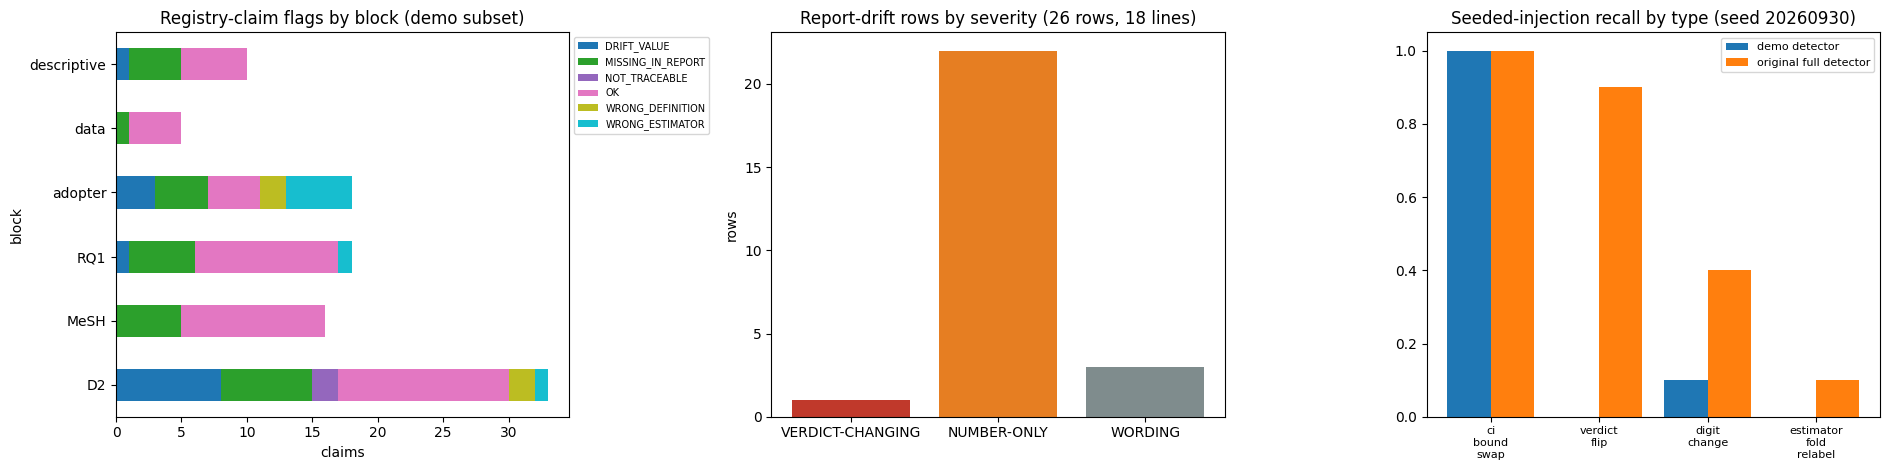

In [19]:
cdf = pd.DataFrame(claims)
cdf["expected_flag"] = [CLAIM_BY_ID[i]["expected_flag"] for i in cdf.id]
cdf["same_as_original"] = cdf.flag == cdf.expected_flag
print(f"Flag reproduced for {cdf.same_as_original.sum()}/{len(cdf)} claims "
      f"({100 * cdf.same_as_original.mean():.1f}%) vs the original full run")
if (~cdf.same_as_original).any():
    display(cdf.loc[~cdf.same_as_original, ["id", "report_value", "source_value", "flag", "expected_flag"]])

print("\nFlag counts by block (demo subset):")
display(pd.crosstab(cdf.block, cdf.flag, margins=True))

print("\nNon-OK claims found in the report (what the paper must correct):")
bad = cdf[~cdf.flag.isin(["OK", "MISSING_IN_REPORT"])].copy()
bad["source_value"] = bad.source_value.map(fmt)
bad["recomputed"] = bad.recomputed.map(lambda v: fmt(v) if v != "" else "")
bad["replacement"] = bad.replacement.str.slice(0, 90)
with pd.option_context("display.max_colwidth", 90, "display.width", 250):
    display(bad[["id", "report_line", "report_value", "source_value", "recomputed", "flag", "replacement"]].reset_index(drop=True))

om = data["original_metrics"]
comp = pd.DataFrame([
    ("M1 traceability (curated)", metrics["M1_traceability_curated"], om["M1_traceability_curated"]),
    ("M2 agreement overall", metrics["M2_agreement_overall"], om["M2_agreement_overall"]),
    ("M2 agreement tier R", metrics["M2_agreement_tier_R"], om["M2_agreement_tier_R"]),
    ("M2 agreement tier C", metrics["M2_agreement_tier_C"], om["M2_agreement_tier_C"]),
    ("M3 DRIFT_VALUE", metrics["M3_n_drift_value"], om["M3_n_drift_value"]),
    ("M3 WRONG_ESTIMATOR", metrics["M3_n_wrong_estimator"], om["M3_n_wrong_estimator"]),
    ("M3 NOT_TRACEABLE", metrics["M3_n_not_traceable"], om["M3_n_not_traceable"]),
    ("M4 known-drift recall", metrics["M4_known_drift_recall"], om["M4_known_drift_recall"]),
] + ([("M5 seeded recall (blind seed)", metrics["M5_seeded_recall"], om["M5_seeded_recall"])] if RUN_SEEDED_INJECTION else []),
    columns=["metric", f"demo ({len(claims)} claims, no checks.py / index)", "original full run (319 claims)"])
print("\nDemo vs original metrics (M2 agreement is over a subset enriched for non-OK claims, so it is lower by design):")
display(comp.round(3))

fig, axes = plt.subplots(1, 3, figsize=(19, 4.8))
ct = pd.crosstab(cdf.block, cdf.flag)
ct.plot(kind="barh", stacked=True, ax=axes[0], colormap="tab10")
axes[0].set_title("Registry-claim flags by block (demo subset)")
axes[0].set_xlabel("claims")
axes[0].legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.0, 1.0))

sv = pd.Series(sev).reindex(["VERDICT-CHANGING", "NUMBER-ONLY", "WORDING"]).fillna(0)
axes[1].bar(sv.index, sv.values, color=["#c0392b", "#e67e22", "#7f8c8d"])
axes[1].set_title(f"Report-drift rows by severity ({len(det['drift'])} rows, {len(drift_lines)} lines)")
axes[1].set_ylabel("rows")

if RUN_SEEDED_INJECTION:
    types_ = ["ci_bound_swap", "verdict_flip", "digit_change", "estimator_fold_relabel"]
    x = np.arange(len(types_))
    axes[2].bar(x - 0.2, [inj["recall_by_type"].get(t, 0) for t in types_], 0.4, label="demo detector")
    axes[2].bar(x + 0.2, [om.get(f"M5_recall_{t}", 0) for t in types_], 0.4, label="original full detector")
    axes[2].set_xticks(x)
    axes[2].set_xticklabels([t.replace("_", "\n") for t in types_], fontsize=8)
    axes[2].set_ylim(0, 1.05)
    axes[2].set_title(f"Seeded-injection recall by type (seed {SEED_BLIND})")
    axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()